<a href="https://colab.research.google.com/github/nampeerashatrah256-max/nampeerashatrahfinalproject/blob/main/FINAL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [6]:
file_path = "/content/Metal_Content_of_Consumer_Products_Tested_by_the_NYC_Health_Department_20260423.xlsx"
df = pd.read_excel(file_path)


In [ ]:
print(df.head)

<bound method NDFrame.head of       row_id                           product_type       product_name metal  \
0          1                             Food-Spice    Turmeric powder  Lead   
1          2                             Food-Spice       Cumin powder  Lead   
2          3                             Food-Spice        Cumin seeds  Lead   
3          4                             Food-Spice             Masala  Lead   
4          5                             Food-Candy     Tamarind Candy  Lead   
...      ...                                    ...                ...   ...   
8489    8490  Dietary Supplement/Medications/Remedy  Vitamin D3 Tablet  Lead   
8490    8491                             Food-Spice         Cumin Seed  Lead   
8491    8492                             Food-Spice       Cumin powder  Lead   
8492    8493                             Food-Spice              Cumin  Lead   
8493    8494                             Food-Spice         Castor oil  Lead   

      con

In [7]:
print(df.describe())

            ROW_ID   CONCENTRATION                COLLECTION_DATE
count  8494.000000     8494.000000                           8494
mean   4247.500000    11167.086802  2019-06-27 09:08:36.223216384
min       1.000000       -1.000000            2011-01-04 00:00:00
25%    2124.250000       -1.000000            2017-03-13 00:00:00
50%    4247.500000       -1.000000            2019-08-06 00:00:00
75%    6370.750000        1.200000            2022-09-22 00:00:00
max    8494.000000  1000000.000000            2024-12-31 00:00:00
std    2452.150927    85231.664482                            NaN


**HANDLING MISSING VALUES**

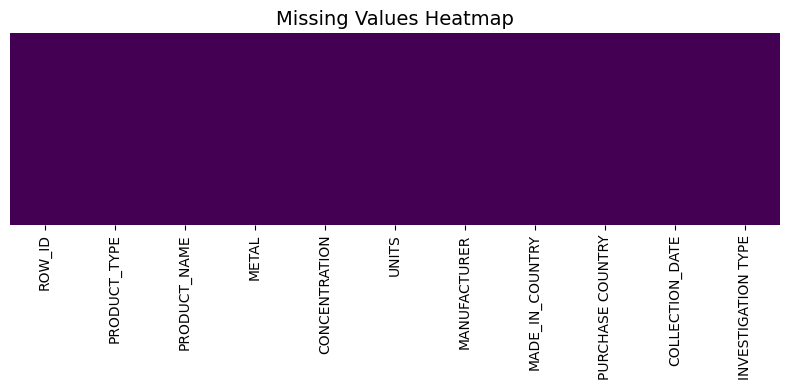


No missing values found in the dataset!


In [8]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nNo missing values found in the dataset!")

UVIVARIATE VISUALIZATIONS

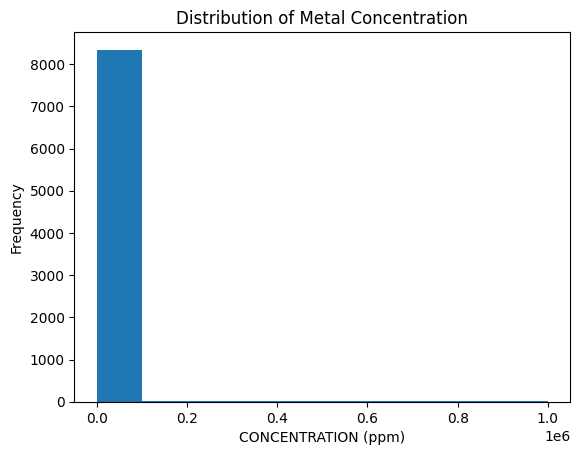

In [9]:
df["CONCENTRATION"] = pd.to_numeric(df["CONCENTRATION"], errors="coerce")
df = df.dropna(subset=["CONCENTRATION"])
plt.figure()
plt.hist(df["CONCENTRATION"])
plt.title("Distribution of Metal Concentration")
plt.xlabel("CONCENTRATION (ppm)")
plt.ylabel("Frequency")
plt.show()

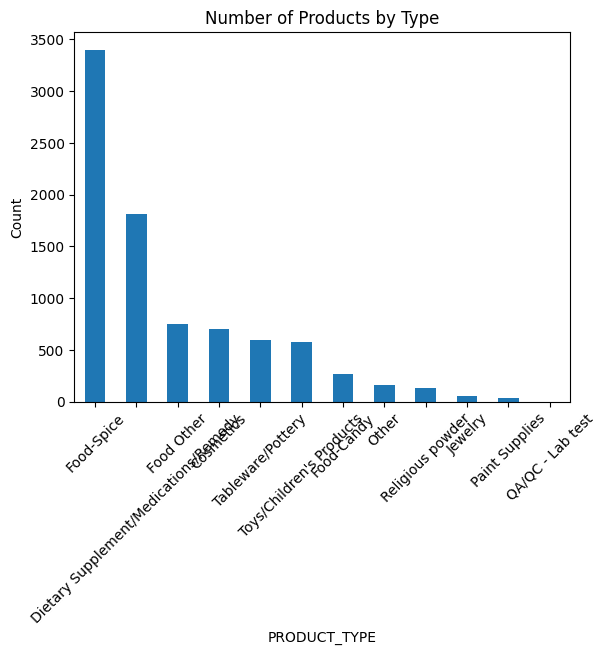

In [10]:
plt.figure()
df["PRODUCT_TYPE"].value_counts().plot(kind="bar")
plt.title("Number of Products by Type")
plt.xlabel("PRODUCT_TYPE")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

<Figure size 640x480 with 0 Axes>

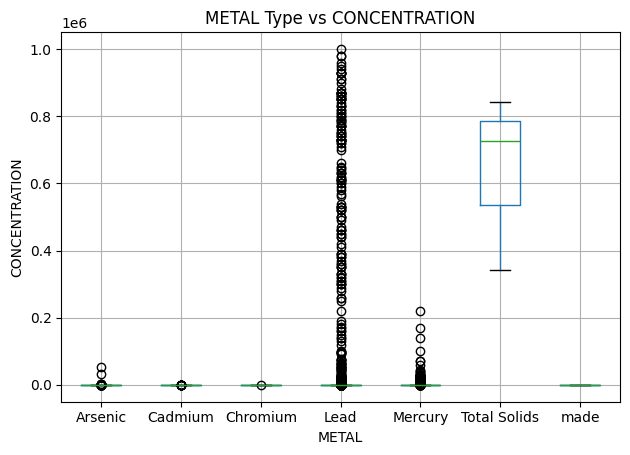

In [11]:
#metal concentration vs metal type
plt.figure()
df.boxplot(column="CONCENTRATION", by="METAL")
plt.title("METAL Type vs CONCENTRATION")
plt.suptitle("")
plt.xlabel("METAL")
plt.ylabel("CONCENTRATION")
plt.tight_layout()
plt.savefig('boxplots.png', dpi=500, bbox_inches='tight')
plt.show()

Text(0, 0.5, 'Count')

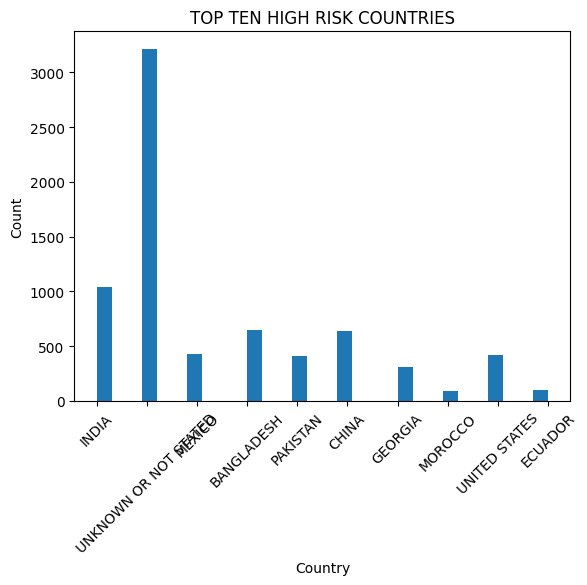

In [12]:
top_countries = df["MADE_IN_COUNTRY"].value_counts().head(10).index
df = df[df["MADE_IN_COUNTRY"].isin(top_countries)]
plt.hist(df["MADE_IN_COUNTRY"], bins=30)
plt.xticks(rotation=45)
plt.title("TOP TEN HIGH RISK COUNTRIES")
plt.xlabel("Country")
plt.ylabel("Count")

DATA CLEANING AND PREPARATION FOR MACHINE LEARNING

In [13]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

target = "concentration"
# Drop rows where target is missing
df = df.dropna(subset=[target])

# 5. Feature / Target split
X = df.drop(columns=[target])
y = df[target]


In [14]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include='object').columns

# 7. Preprocessing pipelines
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

# 8. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
  #MACHINE LEARNING MODELS
 #RANDOM FOREST (CLASSICAL)
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(n_estimators=150, random_state=42))
])

#  Neural Network (MLP)
mlp_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", MLPRegressor(hidden_layer_sizes=(128, 64),
                           max_iter=4000,
                           random_state=42))
])
#train models
rf_pipeline.fit(X_train, y_train)
mlp_pipeline.fit(X_train, y_train)

# 11. Predictions
rf_preds = rf_pipeline.predict(X_test)
mlp_preds = mlp_pipeline.predict(X_test)

mlp_preds = np.maximum(mlp_preds, 0)
rf_preds = np.maximum(rf_preds, 0)

print("Random Forest Predictions:", rf_preds[:5])
print("Neural Network (MLP) Predictions:", mlp_preds[:5])


Random Forest Predictions: [0.00000000e+00 0.00000000e+00 3.34290667e-01 6.37933333e+02
 0.00000000e+00]
Neural Network (MLP) Predictions: [1472.02501444 8061.62908371  396.27599356    0.         1011.14281928]


In [18]:
# 12. Evaluation
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))



evaluate(y_test, rf_preds, "Random Forest")
evaluate(y_test, mlp_preds, "Neural Network (MLP)")


Random Forest
MSE: 2603989058.6016293
R2: 0.608251079223628

Neural Network (MLP)
MSE: 8886973017.56333
R2: -0.33697262555655905


In [24]:
import gradio as gr
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

#The prediction function
def predict(product_type, metal, made_in_country):
    #DataFrame for the input with the same columns as X_train
    sample_input = X_train.iloc[[0]].copy()

    # Update the features provided by the user
    sample_input['product_type'] = product_type
    sample_input['metal'] = metal
    sample_input['made_in_country'] = made_in_country

    #predictions using both models
    rf_prediction = rf_pipeline.predict(sample_input)[0]
    mlp_prediction = mlp_pipeline.predict(sample_input)[0]

    #predictions are non-negative
    rf_prediction = max(0, rf_prediction)
    mlp_prediction = max(0, mlp_prediction)

    return (f"Random Forest Prediction: {rf_prediction:.2f} ppm\n"
            f"Neural Network (MLP) Prediction: {mlp_prediction:.2f} ppm")

#unique categories for dropdowns from the preprocessed df (or X)
products = sorted(df['product_type'].unique().tolist())
metals = sorted(df['metal'].unique().tolist())
countries = sorted(df['made_in_country'].unique().tolist())

# evaluation metrics for display in Gradio
rf_mse = mean_squared_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

mlp_mse = mean_squared_error(y_test, mlp_preds)
mlp_r2 = r2_score(y_test, mlp_preds)

with gr.Blocks() as demo:
    gr.Markdown("# 🧪 Metal Concentration Prediction (Regression)")

    gr.Markdown("## Model Performance")
    gr.Markdown(f"### Random Forest Performance:")
    gr.Markdown(f"MSE: {rf_mse:.2f}")
    gr.Markdown(f"R2: {rf_r2:.2f}")

    gr.Markdown(f"### Neural Network (MLP) Performance:")
    gr.Markdown(f"MSE: {mlp_mse:.2f}")
    gr.Markdown(f"R2: {mlp_r2:.2f}")

    gr.Markdown("## 🔍 Predict Metal Concentration")

    product_input = gr.Dropdown(products, label="Product Type")
    metal_input = gr.Dropdown(metals, label="Metal")
    country_input = gr.Dropdown(countries, label="Country")
    output = gr.Textbox(label="Predicted Concentration")

    btn = gr.Button("Predict")

    btn.click(predict, inputs=[product_input, metal_input, country_input], outputs=output)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://91d75f41ca3232455d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
